In [36]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

FILE_1 = "dailyActivity.csv"
FILE_2 = "dailyActivity (1).csv"

df1 = pd.read_csv(FILE_1)
df2 = pd.read_csv(FILE_2)

print("File 1:", df1.shape)
print("File 2:", df2.shape)

File 1: (1021, 13)
File 2: (934, 13)


In [37]:
print("=== FILE 1 ===")
display(df1.head())
print("\nColumns:")
print(df1.columns.tolist())

print("\n=== FILE 2 ===")
display(df2.head())
print("\nColumns:")
print(df2.columns.tolist())

=== FILE 1 ===


,Id,ActivityDay,Calories,minutes_instances,SedentaryMinutes,LightActiveMinutes,ModeratelyActiveMinutes,VeryActiveMinutes,Steps,TotalMinutesAsleep,HalfDream,MinutesInBed,SleepsInstances
0,1503960366,2016-03-12,2228,1440,1056,216,60,108,19675,0.00,0.00,0.00,0.00
1,1503960366,2016-03-13,2101,1440,1106,197,32,105,17106,411.00,15.00,0.00,1.00
2,1503960366,2016-03-14,1829,1440,1142,228,28,42,10023,354.00,27.00,5.00,1.00
3,1503960366,2016-03-15,2112,1440,1037,260,87,56,15384,312.00,16.00,7.00,1.00
4,1503960366,2016-03-16,1965,1440,1122,198,55,65,13498,333.00,28.00,5.00,2.00



Columns:
['Id', 'ActivityDay', 'Calories', 'minutes_instances', 'SedentaryMinutes', 'LightActiveMinutes', 'ModeratelyActiveMinutes', 'VeryActiveMinutes', 'Steps', 'TotalMinutesAsleep', 'HalfDream', 'MinutesInBed', 'SleepsInstances']

=== FILE 2 ===


,Id,ActivityDay,Calories,minutes_instances,SedentaryMinutes,LightActiveMinutes,ModeratelyActiveMinutes,VeryActiveMinutes,Steps,TotalMinutesAsleep,HalfDream,MinutesInBed,SleepsInstances
0,1503960366,2016-04-12,1985,1440,1074,254,64,48,13158,327.00,13.00,6.00,1.00
1,1503960366,2016-04-13,1798,1440,1183,160,53,44,10735,384.00,11.00,12.00,2.00
2,1503960366,2016-04-14,1777,1440,1218,125,44,53,10460,0.00,0.00,0.00,0.00
3,1503960366,2016-04-15,1745,1440,1168,185,53,34,9685,412.00,22.00,8.00,1.00
4,1503960366,2016-04-16,1864,1440,1173,156,49,62,12669,372.00,20.00,8.00,3.00



Columns:
['Id', 'ActivityDay', 'Calories', 'minutes_instances', 'SedentaryMinutes', 'LightActiveMinutes', 'ModeratelyActiveMinutes', 'VeryActiveMinutes', 'Steps', 'TotalMinutesAsleep', 'HalfDream', 'MinutesInBed', 'SleepsInstances']


In [38]:
print("Same columns:", list(df1.columns) == list(df2.columns))

print("\nColumns only in file 1:")
print(set(df1.columns) - set(df2.columns))

print("\nColumns only in file 2:")
print(set(df2.columns) - set(df1.columns))

Same columns: True

Columns only in file 1:
set()

Columns only in file 2:
set()


In [39]:
print("=== FILE 1 ===")
display(df1.dtypes.to_frame("dtype"))

print("\n=== FILE 2 ===")
display(df2.dtypes.to_frame("dtype"))

=== FILE 1 ===


,dtype
Id,int64
ActivityDay,object
Calories,int64
minutes_instances,int64
SedentaryMinutes,int64
LightActiveMinutes,int64
ModeratelyActiveMinutes,int64
VeryActiveMinutes,int64
Steps,int64
TotalMinutesAsleep,float64



=== FILE 2 ===


,dtype
Id,int64
ActivityDay,object
Calories,int64
minutes_instances,int64
SedentaryMinutes,int64
LightActiveMinutes,int64
ModeratelyActiveMinutes,int64
VeryActiveMinutes,int64
Steps,int64
TotalMinutesAsleep,float64


In [40]:
def missing_report(df, name):
    result = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100
    })
    
    result = result.sort_values("missing_count", ascending=False)
    
    print(f"=== {name} ===")
    display(result)

missing_report(df1, "File 1")
missing_report(df2, "File 2")

=== File 1 ===


,missing_count,missing_pct
Id,0,0.00
ActivityDay,0,0.00
Calories,0,0.00
minutes_instances,0,0.00
SedentaryMinutes,0,0.00
LightActiveMinutes,0,0.00
ModeratelyActiveMinutes,0,0.00
VeryActiveMinutes,0,0.00
Steps,0,0.00
TotalMinutesAsleep,0,0.00


=== File 2 ===


,missing_count,missing_pct
Id,0,0.00
ActivityDay,0,0.00
Calories,0,0.00
minutes_instances,0,0.00
SedentaryMinutes,0,0.00
LightActiveMinutes,0,0.00
ModeratelyActiveMinutes,0,0.00
VeryActiveMinutes,0,0.00
Steps,0,0.00
TotalMinutesAsleep,0,0.00


In [41]:
print("Full duplicate rows:")
print("File 1:", df1.duplicated().sum())
print("File 2:", df2.duplicated().sum())

Full duplicate rows:
File 1: 0
File 2: 0


In [42]:
KEY = ["Id", "ActivityDay"]

print("Duplicate business keys:")
print("File 1:", df1.duplicated(KEY).sum())
print("File 2:", df2.duplicated(KEY).sum())

Duplicate business keys:
File 1: 0
File 2: 0


In [43]:
duplicates_1 = df1[df1.duplicated(KEY, keep=False)].sort_values(KEY)
duplicates_2 = df2[df2.duplicated(KEY, keep=False)].sort_values(KEY)

print("File 1 duplicate keys:")
display(duplicates_1)

print("File 2 duplicate keys:")
display(duplicates_2)

File 1 duplicate keys:


,Id,ActivityDay,Calories,minutes_instances,SedentaryMinutes,LightActiveMinutes,ModeratelyActiveMinutes,VeryActiveMinutes,Steps,TotalMinutesAsleep,HalfDream,MinutesInBed,SleepsInstances


File 2 duplicate keys:


,Id,ActivityDay,Calories,minutes_instances,SedentaryMinutes,LightActiveMinutes,ModeratelyActiveMinutes,VeryActiveMinutes,Steps,TotalMinutesAsleep,HalfDream,MinutesInBed,SleepsInstances


In [44]:
numeric_cols = df1.select_dtypes(include=np.number).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

display(
    df1[numeric_cols].describe().T
)

Numeric columns:
['Id', 'Calories', 'minutes_instances', 'SedentaryMinutes', 'LightActiveMinutes', 'ModeratelyActiveMinutes', 'VeryActiveMinutes', 'Steps', 'TotalMinutesAsleep', 'HalfDream', 'MinutesInBed', 'SleepsInstances']


,count,mean,std,min,25%,50%,75%,max
Id,"1,021.00","4,888,233,443.56","2,422,146,227.89","1,503,960,366.00","2,347,167,796.00","4,558,609,924.00","6,962,181,067.00","8,877,689,391.00"
Calories,"1,021.00","2,223.88",740.47,164.00,"1,776.00","2,100.00","2,665.00","4,778.00"
minutes_instances,"1,021.00","1,415.32",147.37,180.00,"1,440.00","1,440.00","1,440.00","1,440.00"
SedentaryMinutes,"1,021.00","1,204.17",184.34,164.00,"1,117.00","1,192.00","1,328.00","1,440.00"
LightActiveMinutes,"1,021.00",137.68,95.78,0.00,65.00,142.00,205.00,701.00
ModeratelyActiveMinutes,"1,021.00",50.43,51.57,0.00,10.00,37.00,74.00,327.00
VeryActiveMinutes,"1,021.00",23.04,34.87,0.00,0.00,6.00,34.00,250.00
Steps,"1,021.00","6,751.51","5,605.88",0.00,"2,030.00","6,248.00","10,461.00","37,322.00"
TotalMinutesAsleep,"1,021.00",178.97,222.31,0.00,0.00,0.00,405.00,901.00
HalfDream,"1,021.00",12.68,25.21,0.00,0.00,0.00,19.00,306.00


In [45]:
display(
    df2[numeric_cols].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Id,934.00,"4,846,554,293.88","2,420,425,087.67","1,503,960,366.00","2,320,127,002.00","4,445,114,986.00","6,962,181,067.00","8,877,689,391.00"
Calories,934.00,"2,303.63",693.55,65.00,"1,828.25","2,124.00","2,781.50","4,552.00"
minutes_instances,934.00,"1,419.25",122.50,60.00,"1,440.00","1,440.00","1,440.00","1,440.00"
SedentaryMinutes,934.00,"1,186.22",156.07,60.00,"1,110.00","1,182.00","1,275.00","1,440.00"
LightActiveMinutes,934.00,150.80,88.33,0.00,97.00,152.00,204.00,430.00
ModeratelyActiveMinutes,934.00,56.22,47.35,0.00,18.00,46.00,84.75,261.00
VeryActiveMinutes,934.00,26.01,35.75,0.00,0.00,10.00,40.00,230.00
Steps,934.00,"7,573.39","5,100.94",0.00,"3,709.00","7,362.00","10,692.25","36,019.00"
TotalMinutesAsleep,934.00,183.76,218.58,0.00,0.00,0.00,400.00,778.00
HalfDream,934.00,14.94,31.70,0.00,0.00,0.00,20.00,227.00


In [46]:
def negative_values_report(df, name):
    result = {}

    for col in numeric_cols:
        count = (df[col] < 0).sum()
        if count > 0:
            result[col] = count

    print(f"=== {name} ===")
    
    if result:
        display(pd.Series(result, name="negative_count"))
    else:
        print("No negative values found.")

negative_values_report(df1, "File 1")
negative_values_report(df2, "File 2")

=== File 1 ===
No negative values found.
=== File 2 ===
No negative values found.


In [47]:
def consistency_checks(df, name):
    print(f"=== {name} ===")
    
    # 1. Сумма типов активности
    activity_cols = [
        "SedentaryMinutes",
        "LightActiveMinutes",
        "ModeratelyActiveMinutes",
        "VeryActiveMinutes"
    ]
    
    if all(col in df.columns for col in activity_cols + ["minutes_instances"]):
        activity_sum = df[activity_cols].sum(axis=1)
        
        mismatch = ~np.isclose(
            activity_sum,
            df["minutes_instances"],
            equal_nan=True
        )
        
        print("Activity minutes != minutes_instances:", mismatch.sum())
    
    # 2. Sleep <= time in bed
    if all(col in df.columns for col in ["TotalMinutesAsleep", "MinutesInBed"]):
        mask = (
            df["TotalMinutesAsleep"].notna() &
            df["MinutesInBed"].notna() &
            (df["TotalMinutesAsleep"] > df["MinutesInBed"])
        )
        
        print("TotalMinutesAsleep > MinutesInBed:", mask.sum())
    
    # 3. Minutes per day
    if "minutes_instances" in df.columns:
        mask = df["minutes_instances"] > 1440
        print("minutes_instances > 1440:", mask.sum())
        
    # 4. Future dates
    if "ActivityDay" in df.columns:
        dates = pd.to_datetime(df["ActivityDay"], errors="coerce")
        future = dates > pd.Timestamp.today().normalize()
        print("Future ActivityDay:", future.sum())

consistency_checks(df1, "File 1")
consistency_checks(df2, "File 2")

=== File 1 ===
Activity minutes != minutes_instances: 0
TotalMinutesAsleep > MinutesInBed: 457
minutes_instances > 1440: 0
Future ActivityDay: 0
=== File 2 ===
Activity minutes != minutes_instances: 0
TotalMinutesAsleep > MinutesInBed: 439
minutes_instances > 1440: 0
Future ActivityDay: 0


In [48]:
def date_report(df, name):
    dates = pd.to_datetime(df["ActivityDay"], errors="coerce")
    
    print(f"=== {name} ===")
    print("Invalid dates:", dates.isna().sum())
    print("Min date:", dates.min())
    print("Max date:", dates.max())
    print("Unique dates:", dates.nunique())

date_report(df1, "File 1")
date_report(df2, "File 2")

=== File 1 ===
Invalid dates: 0
Min date: 2016-03-12 00:00:00
Max date: 2016-04-12 00:00:00
Unique dates: 32
=== File 2 ===
Invalid dates: 0
Min date: 2016-04-12 00:00:00
Max date: 2016-05-12 00:00:00
Unique dates: 31


In [49]:
def user_report(df, name):
    print(f"=== {name} ===")
    print("Unique users:", df["Id"].nunique())
    print("Rows:", len(df))
    
    records_per_user = df.groupby("Id").size()
    
    display(records_per_user.describe())

user_report(df1, "File 1")
user_report(df2, "File 2")

=== File 1 ===
Unique users: 34
Rows: 1021


count   34.00
mean    30.03
std      5.51
min      1.00
25%     30.25
50%     32.00
75%     32.00
max     32.00
dtype: float64

=== File 2 ===
Unique users: 33
Rows: 934


count   33.00
mean    28.30
std      5.68
min      4.00
25%     28.00
50%     31.00
75%     31.00
max     31.00
dtype: float64

In [50]:
users_1 = set(df1["Id"].dropna().unique())
users_2 = set(df2["Id"].dropna().unique())

print("Users only in File 1:", len(users_1 - users_2))
print("Users only in File 2:", len(users_2 - users_1))
print("Users in both:", len(users_1 & users_2))

Users only in File 1: 2
Users only in File 2: 1
Users in both: 32


In [51]:
df = pd.concat(
    [df1, df2],
    ignore_index=True
)

print("Combined dataset:", df.shape)
display(df.head())

Combined dataset: (1955, 13)


,Id,ActivityDay,Calories,minutes_instances,SedentaryMinutes,LightActiveMinutes,ModeratelyActiveMinutes,VeryActiveMinutes,Steps,TotalMinutesAsleep,HalfDream,MinutesInBed,SleepsInstances
0,1503960366,2016-03-12,2228,1440,1056,216,60,108,19675,0.00,0.00,0.00,0.00
1,1503960366,2016-03-13,2101,1440,1106,197,32,105,17106,411.00,15.00,0.00,1.00
2,1503960366,2016-03-14,1829,1440,1142,228,28,42,10023,354.00,27.00,5.00,1.00
3,1503960366,2016-03-15,2112,1440,1037,260,87,56,15384,312.00,16.00,7.00,1.00
4,1503960366,2016-03-16,1965,1440,1122,198,55,65,13498,333.00,28.00,5.00,2.00


In [52]:
print("Full duplicate rows:", df.duplicated().sum())
print("Duplicate business keys:", df.duplicated(KEY).sum())

Full duplicate rows: 0
Duplicate business keys: 20


In [53]:
duplicate_keys = (
    df[df.duplicated(["Id", "ActivityDay"], keep=False)]
    .sort_values(["Id", "ActivityDay"])
)

print("Duplicate rows:", len(duplicate_keys))
print("Duplicate business keys:", duplicate_keys[["Id", "ActivityDay"]]
      .drop_duplicates().shape[0])

display(duplicate_keys)

Duplicate rows: 40
Duplicate business keys: 20


,Id,ActivityDay,Calories,minutes_instances,SedentaryMinutes,LightActiveMinutes,ModeratelyActiveMinutes,VeryActiveMinutes,Steps,TotalMinutesAsleep,HalfDream,MinutesInBed,SleepsInstances
62,1624580081,2016-04-12,672,660,575,85,0,0,6498,0.00,0.00,0.00,0.00
1051,1624580081,2016-04-12,1432,1440,1294,130,14,2,8163,0.00,0.00,0.00,0.00
124,1844505072,2016-04-12,393,420,420,0,0,0,0,0.00,0.00,0.00,0.00
1112,1844505072,2016-04-12,2031,1440,1101,300,38,1,6697,0.00,0.00,0.00,0.00
156,1927972279,2016-04-12,939,660,657,3,0,0,24,482.00,16.00,0.00,2.00
1143,1927972279,2016-04-12,2193,1440,1385,55,0,0,678,626.00,24.00,1.00,3.00
188,2022484408,2016-04-12,1130,660,550,40,29,41,6667,0.00,0.00,0.00,0.00
1174,2022484408,2016-04-12,2390,1440,1156,153,89,42,11875,0.00,0.00,0.00,0.00
220,2026352035,2016-04-12,558,600,543,52,5,0,957,341.00,13.00,0.00,1.00
1205,2026352035,2016-04-12,1460,1440,1248,159,29,4,4414,504.00,33.00,5.00,2.00


In [54]:
df1_check = df1.copy()
df1_check["source_file"] = "file_1"

df2_check = df2.copy()
df2_check["source_file"] = "file_2"

df_sources = pd.concat(
    [df1_check, df2_check],
    ignore_index=True
)

duplicates = df_sources[
    df_sources.duplicated(["Id", "ActivityDay"], keep=False)
].sort_values(["Id", "ActivityDay"])

display(
    duplicates[
        ["Id", "ActivityDay", "source_file",
         "Calories", "Steps",
         "TotalMinutesAsleep", "MinutesInBed"]
    ]
)

,Id,ActivityDay,source_file,Calories,Steps,TotalMinutesAsleep,MinutesInBed
62,1624580081,2016-04-12,file_1,672,6498,0.00,0.00
1051,1624580081,2016-04-12,file_2,1432,8163,0.00,0.00
124,1844505072,2016-04-12,file_1,393,0,0.00,0.00
1112,1844505072,2016-04-12,file_2,2031,6697,0.00,0.00
156,1927972279,2016-04-12,file_1,939,24,482.00,0.00
1143,1927972279,2016-04-12,file_2,2193,678,626.00,1.00
188,2022484408,2016-04-12,file_1,1130,6667,0.00,0.00
1174,2022484408,2016-04-12,file_2,2390,11875,0.00,0.00
220,2026352035,2016-04-12,file_1,558,957,341.00,0.00
1205,2026352035,2016-04-12,file_2,1460,4414,504.00,5.00


In [55]:
sleep_problem = df[
    df["TotalMinutesAsleep"] > df["MinutesInBed"]
].copy()

print("Rows with TotalMinutesAsleep > MinutesInBed:",
      len(sleep_problem))

display(
    sleep_problem[
        ["Id", "ActivityDay",
         "TotalMinutesAsleep",
         "HalfDream",
         "MinutesInBed",
         "SleepsInstances"]
    ].head(20)
)

Rows with TotalMinutesAsleep > MinutesInBed: 896


,Id,ActivityDay,TotalMinutesAsleep,HalfDream,MinutesInBed,SleepsInstances
1,1503960366,2016-03-13,411.00,15.00,0.00,1.00
2,1503960366,2016-03-14,354.00,27.00,5.00,1.00
3,1503960366,2016-03-15,312.00,16.00,7.00,1.00
4,1503960366,2016-03-16,333.00,28.00,5.00,2.00
5,1503960366,2016-03-17,402.00,34.00,1.00,1.00
6,1503960366,2016-03-18,379.00,26.00,6.00,1.00
7,1503960366,2016-03-19,447.00,20.00,1.00,1.00
8,1503960366,2016-03-20,469.00,7.00,0.00,1.00
9,1503960366,2016-03-21,390.00,30.00,7.00,1.00
11,1503960366,2016-03-23,281.00,13.00,3.00,1.00


In [56]:
display(
    sleep_problem[
        ["TotalMinutesAsleep",
         "HalfDream",
         "MinutesInBed",
         "SleepsInstances"]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
TotalMinutesAsleep,896.00,395.49,146.02,2.00,332.75,417.00,486.25,901.00
HalfDream,896.00,29.75,35.53,0.00,12.00,21.00,32.00,306.00
MinutesInBed,896.00,4.40,8.68,0.00,1.00,3.00,5.00,129.00
SleepsInstances,896.00,1.69,0.69,1.00,1.00,2.00,2.00,6.00


In [57]:
print("TotalMinutesAsleep > 24 hours:",
      (df["TotalMinutesAsleep"] > 1440).sum())

print("MinutesInBed > 24 hours:",
      (df["MinutesInBed"] > 1440).sum())

TotalMinutesAsleep > 24 hours: 0
MinutesInBed > 24 hours: 0


In [58]:
display(
    df["minutes_instances"].value_counts().sort_index()
)

minutes_instances
60         1
180        2
240        2
300        1
360        2
420        2
480        3
540        1
600       11
660        6
720        6
780        3
840        1
900        5
960        7
1020       2
1080       1
1200       2
1260       1
1320       2
1380       3
1440    1891
Name: count, dtype: int64

In [59]:
print("Rows with incomplete daily interval:",
      (df["minutes_instances"] < 1440).sum())

display(
    df.loc[
        df["minutes_instances"] < 1440,
        ["Id", "ActivityDay", "minutes_instances",
         "SedentaryMinutes",
         "LightActiveMinutes",
         "ModeratelyActiveMinutes",
         "VeryActiveMinutes"]
    ].head(20)
)

Rows with incomplete daily interval: 64


,Id,ActivityDay,minutes_instances,SedentaryMinutes,LightActiveMinutes,ModeratelyActiveMinutes,VeryActiveMinutes
62,1624580081,2016-04-12,660,575,85,0,0
92,1644430081,2016-04-10,240,205,25,5,5
124,1844505072,2016-04-12,420,420,0,0,0
156,1927972279,2016-04-12,660,657,3,0,0
188,2022484408,2016-04-12,660,550,40,29,41
220,2026352035,2016-04-12,600,543,52,5,0
252,2320127002,2016-04-12,660,600,51,5,4
284,2347167796,2016-04-12,420,420,0,0,0
315,2873212765,2016-04-11,1200,845,290,55,10
316,2891001357,2016-04-05,720,600,120,0,0


In [60]:
sleep_cols = [
    "TotalMinutesAsleep",
    "HalfDream",
    "MinutesInBed",
    "SleepsInstances"
]

display(
    df[sleep_cols].corr()
)

,TotalMinutesAsleep,HalfDream,MinutesInBed,SleepsInstances
TotalMinutesAsleep,1.00,0.49,0.35,0.89
HalfDream,0.49,1.00,0.48,0.45
MinutesInBed,0.35,0.48,1.00,0.33
SleepsInstances,0.89,0.45,0.33,1.00


In [61]:
for col in sleep_cols:
    print(f"\n=== {col} ===")
    print("Zero:", (df[col] == 0).sum())
    print("Non-zero:", (df[col] != 0).sum())


=== TotalMinutesAsleep ===
Zero: 1059
Non-zero: 896

=== HalfDream ===
Zero: 1069
Non-zero: 886

=== MinutesInBed ===
Zero: 1262
Non-zero: 693

=== SleepsInstances ===
Zero: 1057
Non-zero: 898


In [62]:
sleep_normal = df[
    (df["TotalMinutesAsleep"] > 0) &
    (df["HalfDream"] > 0) &
    (df["MinutesInBed"] > 0)
]

display(
    sleep_normal[
        ["Id", "ActivityDay",
         "TotalMinutesAsleep",
         "HalfDream",
         "MinutesInBed",
         "SleepsInstances"]
    ].head(20)
)

,Id,ActivityDay,TotalMinutesAsleep,HalfDream,MinutesInBed,SleepsInstances
2,1503960366,2016-03-14,354.00,27.00,5.00,1.00
3,1503960366,2016-03-15,312.00,16.00,7.00,1.00
4,1503960366,2016-03-16,333.00,28.00,5.00,2.00
5,1503960366,2016-03-17,402.00,34.00,1.00,1.00
6,1503960366,2016-03-18,379.00,26.00,6.00,1.00
7,1503960366,2016-03-19,447.00,20.00,1.00,1.00
9,1503960366,2016-03-21,390.00,30.00,7.00,1.00
11,1503960366,2016-03-23,281.00,13.00,3.00,1.00
12,1503960366,2016-03-24,303.00,37.00,4.00,1.00
13,1503960366,2016-03-25,351.00,32.00,3.00,1.00


In [63]:
sleep_logic = pd.DataFrame({
    "condition": [
        "TotalMinutesAsleep > 0 AND SleepsInstances > 0",
        "TotalMinutesAsleep > 0 AND SleepsInstances = 0",
        "TotalMinutesAsleep = 0 AND SleepsInstances > 0",
        "TotalMinutesAsleep = 0 AND SleepsInstances = 0",
    ],
    "count": [
        ((df["TotalMinutesAsleep"] > 0) & (df["SleepsInstances"] > 0)).sum(),
        ((df["TotalMinutesAsleep"] > 0) & (df["SleepsInstances"] == 0)).sum(),
        ((df["TotalMinutesAsleep"] == 0) & (df["SleepsInstances"] > 0)).sum(),
        ((df["TotalMinutesAsleep"] == 0) & (df["SleepsInstances"] == 0)).sum(),
    ]
})

display(sleep_logic)

,condition,count
0,TotalMinutesAsleep > 0 AND SleepsInstances > 0,896
1,TotalMinutesAsleep > 0 AND SleepsInstances = 0,0
2,TotalMinutesAsleep = 0 AND SleepsInstances > 0,2
3,TotalMinutesAsleep = 0 AND SleepsInstances = 0,1057


In [64]:
half_dream_logic = pd.DataFrame({
    "condition": [
        "TotalMinutesAsleep > 0 AND HalfDream > 0",
        "TotalMinutesAsleep > 0 AND HalfDream = 0",
        "TotalMinutesAsleep = 0 AND HalfDream > 0",
        "TotalMinutesAsleep = 0 AND HalfDream = 0",
    ],
    "count": [
        ((df["TotalMinutesAsleep"] > 0) & (df["HalfDream"] > 0)).sum(),
        ((df["TotalMinutesAsleep"] > 0) & (df["HalfDream"] == 0)).sum(),
        ((df["TotalMinutesAsleep"] == 0) & (df["HalfDream"] > 0)).sum(),
        ((df["TotalMinutesAsleep"] == 0) & (df["HalfDream"] == 0)).sum(),
    ]
})

display(half_dream_logic)

,condition,count
0,TotalMinutesAsleep > 0 AND HalfDream > 0,884
1,TotalMinutesAsleep > 0 AND HalfDream = 0,12
2,TotalMinutesAsleep = 0 AND HalfDream > 0,2
3,TotalMinutesAsleep = 0 AND HalfDream = 0,1057


In [65]:
print("SleepsInstances unique values:")
print(sorted(df["SleepsInstances"].unique()))

print("\nHalfDream unique values sample:")
print(sorted(df["HalfDream"].unique())[:50])

SleepsInstances unique values:
[0.0, 1.0, 2.0, 3.0, 4.0, 6.0]

HalfDream unique values sample:
[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0]


In [66]:
plausibility = {
    "Calories <= 0": (df["Calories"] <= 0).sum(),
    "Steps < 0": (df["Steps"] < 0).sum(),
    "Steps > 50000": (df["Steps"] > 50000).sum(),
    "VeryActiveMinutes > 1440": (df["VeryActiveMinutes"] > 1440).sum(),
    "ModeratelyActiveMinutes > 1440": (df["ModeratelyActiveMinutes"] > 1440).sum(),
    "LightActiveMinutes > 1440": (df["LightActiveMinutes"] > 1440).sum(),
    "SedentaryMinutes > 1440": (df["SedentaryMinutes"] > 1440).sum(),
    "Calories > 5000": (df["Calories"] > 5000).sum(),
}

display(pd.Series(plausibility, name="violations"))

Calories <= 0                     0
Steps < 0                         0
Steps > 50000                     0
VeryActiveMinutes > 1440          0
ModeratelyActiveMinutes > 1440    0
LightActiveMinutes > 1440         0
SedentaryMinutes > 1440           0
Calories > 5000                   0
Name: violations, dtype: int64

In [67]:
activity_sum = (
    df["SedentaryMinutes"]
    + df["LightActiveMinutes"]
    + df["ModeratelyActiveMinutes"]
    + df["VeryActiveMinutes"]
)

activity_check = pd.DataFrame({
    "minutes_instances": df["minutes_instances"],
    "activity_sum": activity_sum,
    "difference": df["minutes_instances"] - activity_sum
})

display(activity_check["difference"].describe())

print(
    "Rows where difference != 0:",
    (activity_check["difference"] != 0).sum()
)

count   1,955.00
mean        0.00
std         0.00
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         0.00
Name: difference, dtype: float64

Rows where difference != 0: 0


In [68]:
dq_summary = pd.DataFrame([
    {
        "rule_id": "DQ-01",
        "dimension": "Completeness",
        "rule": "Id is not null",
        "violations": df["Id"].isna().sum(),
        "total": len(df)
    },
    {
        "rule_id": "DQ-02",
        "dimension": "Validity",
        "rule": "ActivityDay is valid date",
        "violations": pd.to_datetime(
            df["ActivityDay"], errors="coerce"
        ).isna().sum(),
        "total": len(df)
    },
    {
        "rule_id": "DQ-03",
        "dimension": "Uniqueness",
        "rule": "Id + ActivityDay is unique",
        "violations": df.duplicated(
            ["Id", "ActivityDay"], keep=False
        ).sum(),
        "total": len(df)
    },
    {
        "rule_id": "DQ-04",
        "dimension": "Validity",
        "rule": "Numeric values are non-negative",
        "violations": (
            df.select_dtypes(include=np.number)
              .lt(0)
              .any(axis=1)
              .sum()
        ),
        "total": len(df)
    },
    {
        "rule_id": "DQ-05",
        "dimension": "Consistency",
        "rule": "Activity minutes sum equals minutes_instances",
        "violations": (
            activity_sum != df["minutes_instances"]
        ).sum(),
        "total": len(df)
    },
    {
        "rule_id": "DQ-06",
        "dimension": "Validity",
        "rule": "minutes_instances <= 1440",
        "violations": (
            df["minutes_instances"] > 1440
        ).sum(),
        "total": len(df)
    },
    {
        "rule_id": "DQ-07",
        "dimension": "Completeness",
        "rule": "Full daily observation coverage",
        "violations": (
            df["minutes_instances"] < 1440
        ).sum(),
        "total": len(df)
    },
    {
        "rule_id": "DQ-08",
        "dimension": "Consistency",
        "rule": "SleepsInstances > 0 implies TotalMinutesAsleep > 0",
        "violations": (
            (df["SleepsInstances"] > 0) &
            (df["TotalMinutesAsleep"] == 0)
        ).sum(),
        "total": len(df)
    },
    {
        "rule_id": "DQ-09",
        "dimension": "Completeness",
        "rule": "TotalMinutesAsleep > 0 implies HalfDream > 0",
        "violations": (
            (df["TotalMinutesAsleep"] > 0) &
            (df["HalfDream"] == 0)
        ).sum(),
        "total": len(df)
    }
])

dq_summary["pass_rate"] = (
    1 - dq_summary["violations"] / dq_summary["total"]
) * 100

display(dq_summary)

,rule_id,dimension,rule,violations,total,pass_rate
0,DQ-01,Completeness,Id is not null,0,1955,100.00
1,DQ-02,Validity,ActivityDay is valid date,0,1955,100.00
2,DQ-03,Uniqueness,Id + ActivityDay is unique,40,1955,97.95
3,DQ-04,Validity,Numeric values are non-negative,0,1955,100.00
4,DQ-05,Consistency,Activity minutes sum equals minutes_instances,0,1955,100.00
5,DQ-06,Validity,minutes_instances <= 1440,0,1955,100.00
6,DQ-07,Completeness,Full daily observation coverage,64,1955,96.73
7,DQ-08,Consistency,SleepsInstances > 0 implies TotalMinutesAsleep...,2,1955,99.90
8,DQ-09,Completeness,TotalMinutesAsleep > 0 implies HalfDream > 0,12,1955,99.39


In [69]:
dq_summary["pass_rate"] = dq_summary["pass_rate"].round(2)

display(
    dq_summary[
        ["rule_id", "dimension", "rule",
         "violations", "total", "pass_rate"]
    ]
)

,rule_id,dimension,rule,violations,total,pass_rate
0,DQ-01,Completeness,Id is not null,0,1955,100.00
1,DQ-02,Validity,ActivityDay is valid date,0,1955,100.00
2,DQ-03,Uniqueness,Id + ActivityDay is unique,40,1955,97.95
3,DQ-04,Validity,Numeric values are non-negative,0,1955,100.00
4,DQ-05,Consistency,Activity minutes sum equals minutes_instances,0,1955,100.00
5,DQ-06,Validity,minutes_instances <= 1440,0,1955,100.00
6,DQ-07,Completeness,Full daily observation coverage,64,1955,96.73
7,DQ-08,Consistency,SleepsInstances > 0 implies TotalMinutesAsleep...,2,1955,99.90
8,DQ-09,Completeness,TotalMinutesAsleep > 0 implies HalfDream > 0,12,1955,99.39


Data Quality Dashboard

Визуализация результатов проверки качества данных для бизнес-пользователя.

Dashboard показывает:
- общий объём проверенных данных;
- количество DQ-правил и их статусы;
- долю успешно прошедших проверку записей;
- количество нарушений по правилам;
- основные проблемные области.

In [76]:
# Копия результатов DQ для dashboard
dashboard_df = dq_summary.copy()

# Добавляем уровень критичности
dashboard_df["severity"] = dashboard_df["rule_id"].apply(
    lambda x: "Critical" if x in ["DQ-01", "DQ-02", "DQ-03", "DQ-04", "DQ-05", "DQ-06"]
    else "Warning"
)

# Добавляем статус
def get_status(row):
    if row["violations"] == 0:
        return "PASS"
    elif row["severity"] == "Critical":
        return "FAIL"
    else:
        return "WARNING"

dashboard_df["status"] = dashboard_df.apply(get_status, axis=1)

dashboard_df

,rule_id,dimension,rule,violations,total,pass_rate,severity,status
0,DQ-01,Completeness,Id is not null,0,1955,100.00,Critical,PASS
1,DQ-02,Validity,ActivityDay is valid date,0,1955,100.00,Critical,PASS
2,DQ-03,Uniqueness,Id + ActivityDay is unique,40,1955,97.95,Critical,FAIL
3,DQ-04,Validity,Numeric values are non-negative,0,1955,100.00,Critical,PASS
4,DQ-05,Consistency,Activity minutes sum equals minutes_instances,0,1955,100.00,Critical,PASS
5,DQ-06,Validity,minutes_instances <= 1440,0,1955,100.00,Critical,PASS
6,DQ-07,Completeness,Full daily observation coverage,64,1955,96.73,Warning,WARNING
7,DQ-08,Consistency,SleepsInstances > 0 implies TotalMinutesAsleep...,2,1955,99.90,Warning,WARNING
8,DQ-09,Completeness,TotalMinutesAsleep > 0 implies HalfDream > 0,12,1955,99.39,Warning,WARNING


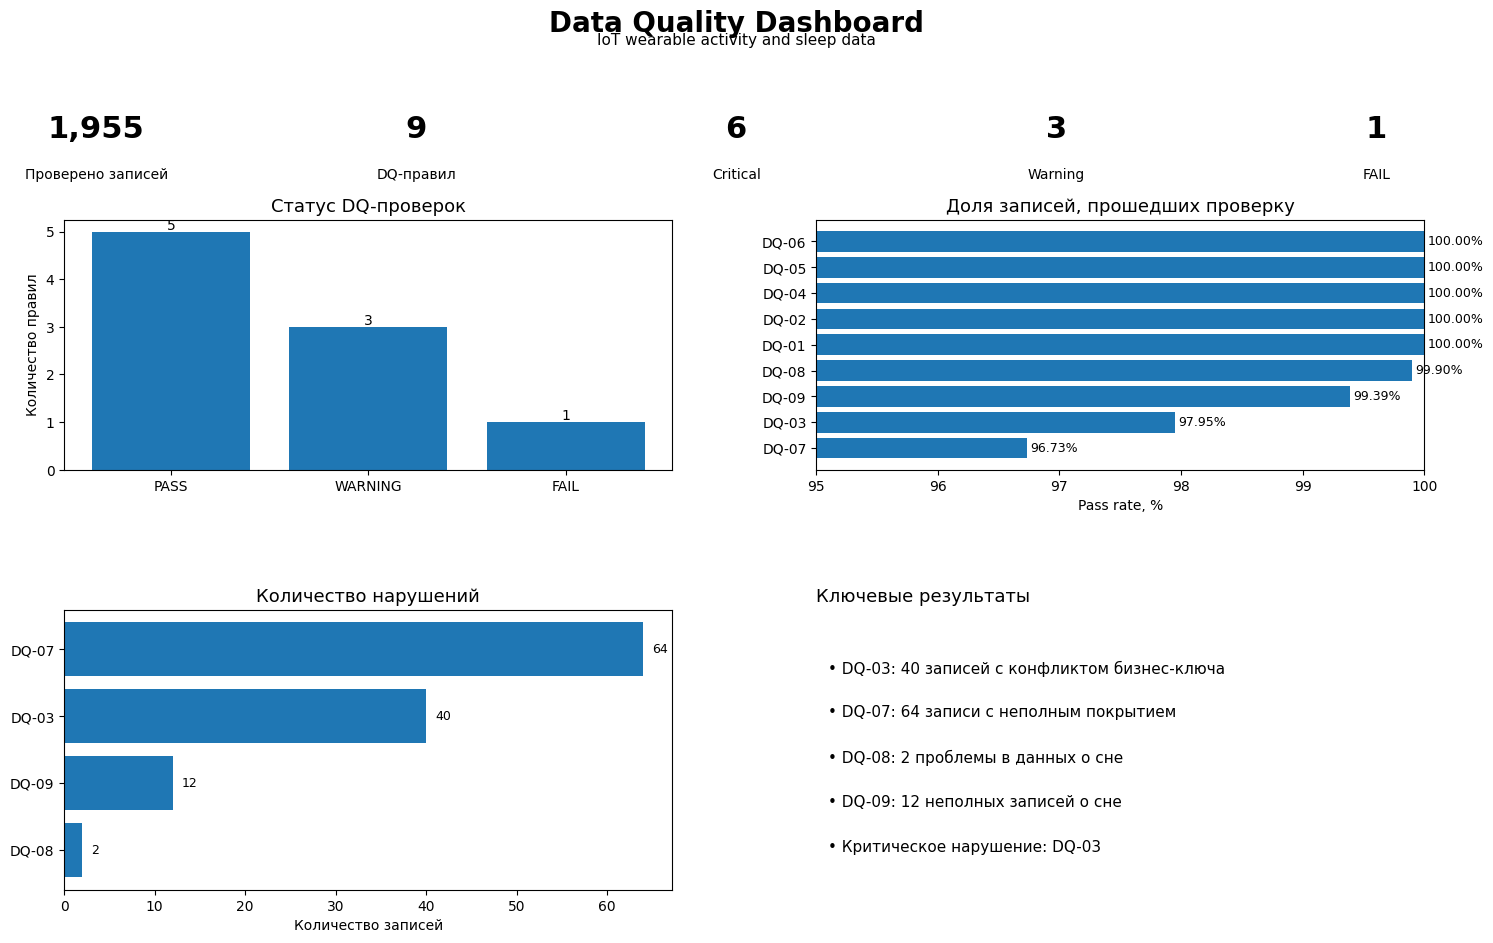

In [78]:
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# KPI
# -----------------------------
total_records = int(dashboard_df["total"].max())
total_rules = len(dashboard_df)

critical_rules = int(
    (dashboard_df["severity"] == "Critical").sum()
)

warning_rules = int(
    (dashboard_df["severity"] == "Warning").sum()
)

fail_rules = int(
    (dashboard_df["status"] == "FAIL").sum()
)

warning_status = int(
    (dashboard_df["status"] == "WARNING").sum()
)

# -----------------------------
# Figure
# -----------------------------
fig = plt.figure(figsize=(16, 10))

# -----------------------------
# Title
# -----------------------------
fig.suptitle(
    "Data Quality Dashboard",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.945,
    "IoT wearable activity and sleep data",
    ha="center",
    fontsize=11
)

# -----------------------------
# KPI blocks
# -----------------------------
kpis = [
    ("Проверено записей", f"{total_records:,}"),
    ("DQ-правил", str(total_rules)),
    ("Critical", str(critical_rules)),
    ("Warning", str(warning_rules)),
    ("FAIL", str(fail_rules)),
]

x_positions = [0.10, 0.30, 0.50, 0.70, 0.90]

for x, (label, value) in zip(x_positions, kpis):
    fig.text(
        x,
        0.86,
        value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )
    fig.text(
        x,
        0.815,
        label,
        ha="center",
        va="center",
        fontsize=10
    )

# -----------------------------
# 1. Status distribution
# -----------------------------
ax1 = fig.add_axes([0.08, 0.52, 0.38, 0.25])

status_order = ["PASS", "WARNING", "FAIL"]

status_counts = (
    dashboard_df["status"]
    .value_counts()
    .reindex(status_order, fill_value=0)
)

bars = ax1.bar(
    status_counts.index,
    status_counts.values
)

ax1.set_title("Статус DQ-проверок", fontsize=13)
ax1.set_ylabel("Количество правил")

for bar, value in zip(bars, status_counts.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        str(value),
        ha="center"
    )

# -----------------------------
# 2. Pass rate
# -----------------------------
ax2 = fig.add_axes([0.55, 0.52, 0.38, 0.25])

plot_df = dashboard_df.sort_values("pass_rate")

bars = ax2.barh(
    plot_df["rule_id"],
    plot_df["pass_rate"]
)

ax2.set_title("Доля записей, прошедших проверку", fontsize=13)
ax2.set_xlabel("Pass rate, %")
ax2.set_xlim(95, 100)

for bar, value in zip(bars, plot_df["pass_rate"]):
    ax2.text(
        value + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=9
    )

# -----------------------------
# 3. Violations
# -----------------------------
ax3 = fig.add_axes([0.08, 0.10, 0.38, 0.28])

violations_df = dashboard_df[
    dashboard_df["violations"] > 0
].sort_values("violations")

bars = ax3.barh(
    violations_df["rule_id"],
    violations_df["violations"]
)

ax3.set_title("Количество нарушений", fontsize=13)
ax3.set_xlabel("Количество записей")

for bar, value in zip(
    bars,
    violations_df["violations"]
):
    ax3.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        str(int(value)),
        va="center",
        fontsize=9
    )

# -----------------------------
# 4. Main findings
# -----------------------------
ax4 = fig.add_axes([0.55, 0.10, 0.38, 0.28])
ax4.axis("off")

ax4.set_title(
    "Ключевые результаты",
    fontsize=13,
    loc="left"
)

findings = [
    "• DQ-03: 40 записей с конфликтом бизнес-ключа",
    "• DQ-07: 64 записи с неполным покрытием",
    "• DQ-08: 2 проблемы в данных о сне",
    "• DQ-09: 12 неполных записей о сне",
    "• Критическое нарушение: DQ-03",
]

y = 0.82

for finding in findings:
    ax4.text(
        0.02,
        y,
        finding,
        fontsize=11,
        va="top"
    )
    y -= 0.16

# -----------------------------
# Save
# -----------------------------
plt.savefig(
    "dashboard.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Run history

| Run   | Checks | Passed | Failed |
| ----- | -----: | -----: | -----: |
| 13:31 |      9 |      5 |      4 |
| 13:40 |      9 |      5 |      4 |
